<a href="https://colab.research.google.com/github/mullinskatie7-source/katherine-mullins.github.io/blob/main/Katherine_Mullins_Lakeside_Irrigation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Markdown
# Python Application for Lakeside Irrigation Pump Analysis

**Engineer:** Katherine Mullins

**Completion Date:** 07/18/2026

**Class:** EGN3214

**Assignment #:** 10

**Tool Used:** Colab / Python

## Problem Description

A lakeside property owner wants to pump water from a lake to a garden storage tank located uphill from the shoreline. The goal of this Python application is to calculate the hydraulic requirements for different flow rates and pipe sizes. The program converts mixed units into SI units, calculates flow velocity, Reynolds number, friction factor, total dynamic head, and hydraulic power, then displays the results in both printed form and plotted form. The purpose is to demonstrate how Python can be used as an engineering calculation tool while also showing the required programming skills from the course.

## Methodology

The Python application was designed to solve a lakeside irrigation pump-sizing problem using engineering calculations, unit conversions, data organization, and visualization. The program accepts mixed-unit inputs such as static lift in feet, flow rate in liters per minute, pipe diameter in inches, and pipe length in meters. These inputs are converted into SI units so the hydraulic calculations can be performed consistently. The program then calculates pipe area, water velocity, Reynolds number, friction factor, total dynamic head, and hydraulic power.

The application was structured using functions so each major calculation could be reused and tested separately. NumPy was used for numerical calculations and flow-rate arrays, pandas were used to organize the results into a DataFrame, and Matplotlib was used to create a system-curve plot. The program also uses conditionals to classify the flow regime and make a recommendation, loops to evaluate multiple flow rates, format output to display results clearly, and tuple outputs to return multiple calculated values from a function. This structure demonstrates how Python can be used as an engineering tool for calculation, comparison, and decision-making.


Lakeside Irrigation Pump Analyzer
---------------------------------------------
Input values loaded successfully.
Converted Inputs
---------------------------------------------
Static lift: 40.0 ft = 12.192 m
Target flow: 500.0 L/min = 0.008333 m^3/s
Target flow: 500.0 L/min = 132.09 GPM
Pipe inside diameter: 3.0 in = 0.0762 m
Pipe length: 250.0 m
Target Design Results
---------------------------------------------
Flow (L/min): 500.000
Flow (GPM): 132.086
Velocity (m/s): 1.827
Reynolds Number: 138715.102
Flow Regime: Turbulent
Friction Factor: 0.017
Friction Loss (m): 9.407
Total Dynamic Head (m): 21.599
Total Dynamic Head (ft): 70.862
Hydraulic Power (kW): 1.763
Hydraulic Power (hp): 2.364
Pump Recommendation Check
---------------------------------------------
Candidate pump: Example 3 HP Irrigation Pump
Required flow: 500.0 L/min
Required head: 21.60 m
Pump head available at target flow: 25.00 m

The candidate pump meets the preliminary design requirement.


,Flow_LPM,Flow_GPM,Velocity_m_s,Reynolds_Number,Flow_Regime,Friction_Factor,Friction_Loss_m,Total_Head_m,Total_Head_ft,Hydraulic_Power_kW,Hydraulic_Power_hp
0,100,26.417205,0.365468,27743.02038,Turbulent,0.023875,0.533244,12.725244,41.749487,0.207683,0.278508
1,200,52.834410,0.730935,55486.04076,Turbulent,0.020368,1.819693,14.011693,45.970120,0.457358,0.613327
2,300,79.251616,1.096403,83229.06114,Turbulent,0.018676,3.754208,15.946208,52.316956,0.780754,1.047008
3,400,105.668821,1.461871,110972.08152,Turbulent,0.017608,6.292413,18.484413,60.644401,1.206705,1.618217
4,500,132.086026,1.827338,138715.10190,Turbulent,0.016847,9.406708,21.598708,70.861903,1.762516,2.363573
5,600,158.503231,2.192806,166458.12228,Turbulent,0.016264,13.077537,25.269537,82.905305,2.474479,3.318331
6,700,184.920436,2.558273,194201.14266,Turbulent,0.015798,17.290020,29.482020,96.725789,3.368144,4.516754
7,800,211.337642,2.923741,221944.16304,Turbulent,0.015413,22.032308,34.224308,112.284474,4.468482,5.992332


Flow Rate Analysis Table
-----------------------------------------------------------------------------------------------
Flow (L/min)   Flow (GPM)     Velocity       Head (m)       Head (ft)      Power (hp)     
-----------------------------------------------------------------------------------------------
100            26.42          0.37           12.73          41.75          0.28           
200            52.83          0.73           14.01          45.97          0.61           
300            79.25          1.10           15.95          52.32          1.05           
400            105.67         1.46           18.48          60.64          1.62           
500            132.09         1.83           21.60          70.86          2.36           
600            158.50         2.19           25.27          82.91          3.32           
700            184.92         2.56           29.48          96.73          4.52           
800            211.34         2.92           34.22     

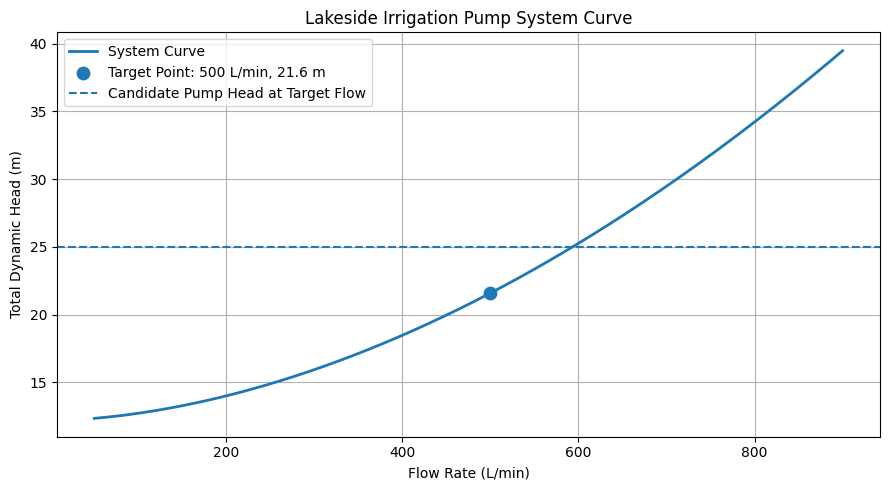

,Pipe_ID_in,Velocity_m_s,Reynolds_Number,Friction_Loss_m,Total_Head_m,Hydraulic_Power_hp
0,2.0,4.111511,208072.652850,66.516495,78.708495,8.613165
1,2.5,2.631367,166458.122280,22.642222,34.834222,3.811951
2,3.0,1.827338,138715.101900,9.406708,21.598708,2.363573
3,4.0,1.027878,104036.326425,2.359693,14.551693,1.592409


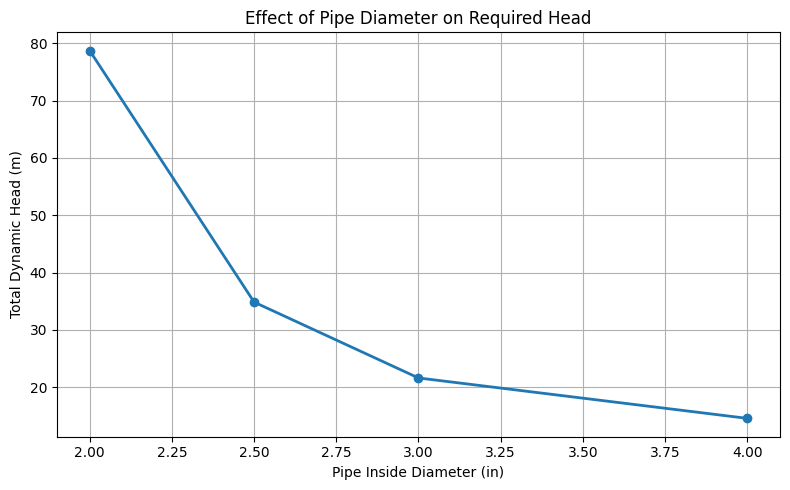

In [1]:
# Step 2: Import required Python libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 3: Unit conversion functions

def feet_to_meters(feet):
    return feet * 0.3048

def inches_to_meters(inches):
    return inches * 0.0254

def liters_per_minute_to_m3_per_second(liters_per_minute):
    return liters_per_minute / 1000 / 60

def m3_per_second_to_liters_per_minute(flow_m3_s):
    return flow_m3_s * 1000 * 60

def liters_per_minute_to_gpm(liters_per_minute):
    return liters_per_minute * 0.264172052

def meters_to_feet(meters):
    return meters / 0.3048

def watts_to_kw(watts):
    return watts / 1000

def watts_to_hp(watts):
    return watts / 745.7

# Step 4: Simple variables: strings, integers, and floats

project_name = "Lakeside Irrigation Pump Analyzer"

# Given system inputs
static_lift_ft = 40.0
target_flow_lpm = 500.0
pipe_id_in = 3.0
pipe_length_m = 250.0

# Water properties at approximately 20 degrees Celsius
water_density = 998.2          # kg/m^3
water_viscosity = 1.002e-3     # Pa*s

# PVC roughness assumption
pipe_roughness_m = 1.5e-6      # m

# Gravity
g = 9.81                       # m/s^2

# Initial assumption: no minor losses
minor_loss_coefficient = 0.0

print(project_name)
print("-" * 45)
print("Input values loaded successfully.")

# Step 5: Convert original inputs to SI units

static_lift_m = feet_to_meters(static_lift_ft)
target_flow_m3_s = liters_per_minute_to_m3_per_second(target_flow_lpm)
pipe_id_m = inches_to_meters(pipe_id_in)

print("Converted Inputs")
print("-" * 45)
print(f"Static lift: {static_lift_ft:.1f} ft = {static_lift_m:.3f} m")
print(f"Target flow: {target_flow_lpm:.1f} L/min = {target_flow_m3_s:.6f} m^3/s")
print(f"Target flow: {target_flow_lpm:.1f} L/min = {liters_per_minute_to_gpm(target_flow_lpm):.2f} GPM")
print(f"Pipe inside diameter: {pipe_id_in:.1f} in = {pipe_id_m:.4f} m")
print(f"Pipe length: {pipe_length_m:.1f} m")

# Step 6: Engineering calculation functions

def calculate_pipe_area(diameter_m):
    area = np.pi * diameter_m**2 / 4
    return area

def calculate_velocity(flow_m3_s, diameter_m):
    area = calculate_pipe_area(diameter_m)
    velocity = flow_m3_s / area
    return velocity

def calculate_reynolds_number(density, velocity, diameter_m, viscosity):
    reynolds = density * velocity * diameter_m / viscosity
    return reynolds

def swamee_jain_friction_factor(reynolds, roughness_m, diameter_m):
    relative_roughness = roughness_m / diameter_m

    friction_factor = 0.25 / (
        np.log10(
            (relative_roughness / 3.7)
            + (5.74 / reynolds**0.9)
        )
    )**2

    return friction_factor

def calculate_friction_head_loss(friction_factor, pipe_length_m, diameter_m, velocity, gravity):
    head_loss = (
        friction_factor
        * (pipe_length_m / diameter_m)
        * (velocity**2 / (2 * gravity))
    )
    return head_loss

def calculate_hydraulic_power(density, gravity, flow_m3_s, total_head_m):
    power_watts = density * gravity * flow_m3_s * total_head_m
    return power_watts

# Step 7: Function returns multiple values as a tuple

def analyze_pump_system(flow_lpm, pipe_diameter_in):
    flow_m3_s = liters_per_minute_to_m3_per_second(flow_lpm)
    diameter_m = inches_to_meters(pipe_diameter_in)

    area_m2 = calculate_pipe_area(diameter_m)
    velocity_m_s = calculate_velocity(flow_m3_s, diameter_m)
    reynolds = calculate_reynolds_number(
        water_density,
        velocity_m_s,
        diameter_m,
        water_viscosity
    )

    # Conditional statement for flow regime and friction factor
    if reynolds < 2300:
        flow_regime = "Laminar"
        friction_factor = 64 / reynolds
    else:
        flow_regime = "Turbulent"
        friction_factor = swamee_jain_friction_factor(
            reynolds,
            pipe_roughness_m,
            diameter_m
        )

    friction_loss_m = calculate_friction_head_loss(
        friction_factor,
        pipe_length_m,
        diameter_m,
        velocity_m_s,
        g
    )

    minor_loss_m = minor_loss_coefficient * (velocity_m_s**2 / (2 * g))
    total_dynamic_head_m = static_lift_m + friction_loss_m + minor_loss_m

    hydraulic_power_w = calculate_hydraulic_power(
        water_density,
        g,
        flow_m3_s,
        total_dynamic_head_m
    )

    # Tuple output
    return (
        area_m2,
        velocity_m_s,
        reynolds,
        flow_regime,
        friction_factor,
        friction_loss_m,
        total_dynamic_head_m,
        hydraulic_power_w
    )

# Step 8: Analyze the target design condition

(
    area_m2,
    velocity_m_s,
    reynolds,
    flow_regime,
    friction_factor,
    friction_loss_m,
    total_dynamic_head_m,
    hydraulic_power_w
) = analyze_pump_system(target_flow_lpm, pipe_id_in)

# Complex variable: dictionary storing related results
target_results = {
    "Flow (L/min)": target_flow_lpm,
    "Flow (GPM)": liters_per_minute_to_gpm(target_flow_lpm),
    "Velocity (m/s)": velocity_m_s,
    "Reynolds Number": reynolds,
    "Flow Regime": flow_regime,
    "Friction Factor": friction_factor,
    "Friction Loss (m)": friction_loss_m,
    "Total Dynamic Head (m)": total_dynamic_head_m,
    "Total Dynamic Head (ft)": meters_to_feet(total_dynamic_head_m),
    "Hydraulic Power (kW)": watts_to_kw(hydraulic_power_w),
    "Hydraulic Power (hp)": watts_to_hp(hydraulic_power_w)
}

print("Target Design Results")
print("-" * 45)

for key, value in target_results.items():
    if isinstance(value, str):
        print(f"{key}: {value}")
    else:
        print(f"{key}: {value:.3f}")

# Step 9: Pump recommendation logic
# Candidate pump capability is assumed for demonstration.

candidate_pump_name = "Example 3 HP Irrigation Pump"
candidate_max_flow_lpm = 600.0
candidate_head_at_target_m = 25.0

print("Pump Recommendation Check")
print("-" * 45)
print(f"Candidate pump: {candidate_pump_name}")
print(f"Required flow: {target_flow_lpm:.1f} L/min")
print(f"Required head: {total_dynamic_head_m:.2f} m")
print(f"Pump head available at target flow: {candidate_head_at_target_m:.2f} m")

if candidate_head_at_target_m >= total_dynamic_head_m and candidate_max_flow_lpm >= target_flow_lpm:
    recommendation = "The candidate pump meets the preliminary design requirement."
else:
    recommendation = "The candidate pump does not meet the preliminary design requirement."

print()
print(recommendation)

# Step 10: Use a NumPy array to analyze multiple flow rates

flow_lpm_array = np.array([100, 200, 300, 400, 500, 600, 700, 800])

results_list = []

for flow_lpm in flow_lpm_array:
    (
        area,
        velocity,
        reynolds,
        regime,
        friction_factor,
        friction_loss,
        total_head,
        power_w
    ) = analyze_pump_system(flow_lpm, pipe_id_in)

    row = {
        "Flow_LPM": flow_lpm,
        "Flow_GPM": liters_per_minute_to_gpm(flow_lpm),
        "Velocity_m_s": velocity,
        "Reynolds_Number": reynolds,
        "Flow_Regime": regime,
        "Friction_Factor": friction_factor,
        "Friction_Loss_m": friction_loss,
        "Total_Head_m": total_head,
        "Total_Head_ft": meters_to_feet(total_head),
        "Hydraulic_Power_kW": watts_to_kw(power_w),
        "Hydraulic_Power_hp": watts_to_hp(power_w)
    }

    results_list.append(row)

# Multidimensional data structure: pandas DataFrame
results_df = pd.DataFrame(results_list)

display(results_df)

# Step 11: Output formatted numeric data

print("Flow Rate Analysis Table")
print("-" * 95)
print(f"{'Flow (L/min)':<15}{'Flow (GPM)':<15}{'Velocity':<15}{'Head (m)':<15}{'Head (ft)':<15}{'Power (hp)':<15}")
print("-" * 95)

for index, row in results_df.iterrows():
    print(
        f"{row['Flow_LPM']:<15.0f}"
        f"{row['Flow_GPM']:<15.2f}"
        f"{row['Velocity_m_s']:<15.2f}"
        f"{row['Total_Head_m']:<15.2f}"
        f"{row['Total_Head_ft']:<15.2f}"
        f"{row['Hydraulic_Power_hp']:<15.2f}"
    )

# Step 12: Plot system curve using Matplotlib

flow_plot_lpm = np.linspace(50, 900, 200)

head_plot_m = []

for flow in flow_plot_lpm:
    analysis = analyze_pump_system(flow, pipe_id_in)
    total_head = analysis[6]
    head_plot_m.append(total_head)

head_plot_m = np.array(head_plot_m)

plt.figure(figsize=(9, 5))

plt.plot(
    flow_plot_lpm,
    head_plot_m,
    label="System Curve",
    linewidth=2
)

plt.scatter(
    target_flow_lpm,
    total_dynamic_head_m,
    s=80,
    label=f"Target Point: {target_flow_lpm:.0f} L/min, {total_dynamic_head_m:.1f} m"
)

plt.axhline(
    candidate_head_at_target_m,
    linestyle="--",
    label="Candidate Pump Head at Target Flow"
)

plt.xlabel("Flow Rate (L/min)")
plt.ylabel("Total Dynamic Head (m)")
plt.title("Lakeside Irrigation Pump System Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Step 13: Compare multiple pipe diameters at the target flow rate

pipe_sizes_in = [2.0, 2.5, 3.0, 4.0]
pipe_size_results = []

for diameter in pipe_sizes_in:
    (
        area,
        velocity,
        reynolds,
        regime,
        friction_factor,
        friction_loss,
        total_head,
        power_w
    ) = analyze_pump_system(target_flow_lpm, diameter)

    pipe_size_results.append({
        "Pipe_ID_in": diameter,
        "Velocity_m_s": velocity,
        "Reynolds_Number": reynolds,
        "Friction_Loss_m": friction_loss,
        "Total_Head_m": total_head,
        "Hydraulic_Power_hp": watts_to_hp(power_w)
    })

pipe_size_df = pd.DataFrame(pipe_size_results)

display(pipe_size_df)

plt.figure(figsize=(8, 5))

plt.plot(
    pipe_size_df["Pipe_ID_in"],
    pipe_size_df["Total_Head_m"],
    marker="o",
    linewidth=2
)

plt.xlabel("Pipe Inside Diameter (in)")
plt.ylabel("Total Dynamic Head (m)")
plt.title("Effect of Pipe Diameter on Required Head")
plt.grid(True)
plt.tight_layout()
plt.show()